<div class='alert alert-success'>

<h1><b>Projeto 2</b></h1>
<h2 style="font-size: 20px">Análise de Partidas de Futebol Masculino e Feminino</h2>

</div>

<div class="alert alert-info" style="font-size:20px">

- <b>Alunos: 
    - Arthur Dantas Freire
    - Edvaldo Gomes Neto</b>
</div>

---
Você trabalha como estagiário de dados para o setor de jornalismo esportivo em um grande portal online, especializado em análises e reportagens de futebol. O departamento acompanha partidas internacionais de futebol masculino e feminino há anos e tem a sensação de que há mais gols nos jogos internacionais femininos do que nos masculinos. Isso daria uma matéria investigativa interessante que os assinantes certamente vão adorar, mas seu chefe afirmou que você precisa fazer um teste de hipótese estatístico válido para ter certeza!

Ao definir o escopo do projeto, você reconhece que o esporte mudou muito ao longo dos anos, e o desempenho provavelmente varia bastante conforme o torneio. Por isso, decide limitar os dados da análise apenas às partidas oficiais da FIFA World Cup (sem incluir eliminatórias) desde 2002-01-01.

Você cria dois conjuntos de dados com os resultados de todas as partidas internacionais oficiais de futebol masculino e feminino desde o século XIX, obtidos por raspagem de uma fonte online confiável. Esses dados estão armazenados em dois arquivos CSV: women_results.csv e men_results.csv.

A pergunta que você quer responder é:

*“Há mais gols nas partidas internacionais de futebol feminino do que nas de futebol masculino?”*

Você assume um nível de significância de 10% e utiliza as seguintes hipóteses nula e alternativa:

- $ H_0 : $ O número médio de gols marcados nas partidas internacionais de futebol feminino é igual ao do
masculino.
-  $ H_A : $ O número médio de gols marcados nas partidas internacionais de futebol feminino é maior do que o
do masculino.

---

<div class="alert alert-info" style="font-size:20px">
<b>Instruções</b>

1. Realize um teste de hipótese apropriado para determinar o p-valor e, assim, o resultado de rejeitar ou não rejeitar a hipótese nula de que o número médio de gols marcados em partidas internacionais femininas é o mesmo que em partidas masculinas. Use um nível de significância de 10%.
2. Para esta análise, use partidas oficiais da FIFA World Cup desde 2002-01-01, e assuma também que cada partida é totalmente independente, ou seja, o momento/forma do time é ignorado.
3. O p-valor e o resultado do teste devem ser armazenados em um dicionário chamado result_dict no formato:

- a) result_dict = {"p_val": p_val, "result": result}

  Onde p_val é o p-valor e result é a string “fail to reject” ou “reject”, dependendo do resultado do teste.
</div>

In [3]:
# Importações
from scipy.stats import mannwhitneyu
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Carregando os datasets
men_results = pd.read_csv("men_results.csv")
women_results = pd.read_csv("women_results.csv")

---

<div class='alert alert-success'>

<h1><b>Filtrando os dataframes para selecionar somente partidas</b></h1>

</div>

In [4]:
# da FIFA World Cup a partir de 1º de Janeiro de 2002
fifa_men_results = men_results[(men_results["tournament"] == "FIFA World Cup") & (men_results["date"] > "2002-01-01")].copy()
fifa_women_results = women_results[(women_results["tournament"] == "FIFA World Cup") & (women_results["date"] > "2002-01-01")].copy()

# Criando uma coluna adicional com o saldo total de gols
fifa_men_results["men_total_goals"] = fifa_men_results["home_score"] + fifa_men_results["away_score"]
fifa_women_results["women_total_goals"] = fifa_women_results["home_score"] + fifa_women_results["away_score"]

# Calculando o total e a média de gols por gênero
total_masculino = fifa_men_results["men_total_goals"].sum()
total_feminino = fifa_women_results["women_total_goals"].sum()

media_masculina = total_masculino / len(fifa_men_results["men_total_goals"])
media_feminina = total_feminino / len(fifa_women_results["women_total_goals"])

print("-" * 35)
print(f"Total de Gols - Homens: {total_masculino}\nMédia de gols: {media_masculina:.2f}")
print(f"\nTotal de Gols - Mulheres: {total_feminino}\nMédia de gols: {media_feminina:.2f}")
print("-" * 35)

-----------------------------------
Total de Gols - Homens: 965
Média de gols: 2.51

Total de Gols - Mulheres: 596
Média de gols: 2.98
-----------------------------------


---

<div class='alert alert-success'>

<h1><b>Análise Exploratória do conjunto de dados masculino</b></h1>

</div>

In [5]:
fifa_men_results.describe()

,Unnamed: 0,home_score,away_score,men_total_goals
count,384.000000,384.000000,384.000000,384.000000
mean,34629.875000,1.375000,1.138021,2.513021
std,6566.923215,1.328538,1.107398,1.652544
min,25164.000000,0.000000,0.000000,0.000000
25%,28769.750000,0.000000,0.000000,1.000000
50%,34557.000000,1.000000,1.000000,2.000000
75%,40385.250000,2.000000,2.000000,3.000000
max,44352.000000,8.000000,7.000000,8.000000


---

<div class='alert alert-success'>

<h1><b>Análise Exploratória do conjunto de dados feminino</b></h1>

</div>

In [6]:
fifa_women_results.describe()

,Unnamed: 0,home_score,away_score,women_total_goals
count,200.000000,200.000000,200.000000,200.000000
mean,3094.485000,1.805000,1.175000,2.980000
std,1010.682192,1.937977,1.289453,2.022387
min,1600.000000,0.000000,0.000000,0.000000
25%,2155.750000,1.000000,0.000000,2.000000
50%,3429.500000,1.000000,1.000000,3.000000
75%,4418.250000,2.000000,2.000000,4.000000
max,4469.000000,13.000000,7.000000,13.000000


<details style="color: #b5f877">
    <summary>
        <font style="font-size: 22px;color: #ffffff">
            <b>Análise de conjuntos</b>
        </font>
    </summary>
<font style='color: #acacac'>

- A partir da análise dos conjuntos é possível afirmar que:
    
1. As partidas femininas tiveram mais gols em média;

2. O desvio-padrão na quantidade de gols em jogos femininos é ligeiramente maior, isso indica que os resultados em jogos femininos são mais dispersos;

3. A mediana indica que metade dos jogos femininos teve até 3 gols, enquanto nos jogos masculinos a mediana foi pelo menos 2 gols

4. Os quartis reforçam a ideia de que as mulheres marcaram mais gols por partida:

    <table style="color: #ffffff">
        <tr>
            <td><b></b></td>
            <td><b>Homens</b></td>
            <td><b>Mulheres</b></td>
        </tr>
        <tr>
            <td><b>25%</b></td>
            <td>1.0</td>
            <td>2.0</td>
        </tr>
        <tr>
            <td><b>50%</b></td>
            <td>2.0</td>
            <td>3.0</td>
        </tr>
        <tr>
            <td><b>75%</b></td>
            <td>3.0</td>
            <td>4.0</td>
        </tr>
    </table>

5. Os valores extremos também são discrepantes, 8 gols foi o máximo de saldo de gols em uma partida masculina, enquanto na feminina o resultado foi de 13 gols

</font>
</details>


In [ ]:
# Verificando o tamanho de cada amostra
print(f"Amostra masculina: {len(fifa_men_results)} entradas")
print(f"Amostra feminina: {len(fifa_women_results)} entradas")

Amostra masculina: 384 entradas
Amostra feminina: 200 entradas


---

<div class='alert alert-success'>

<h1><b>Plotando os dados em um histograma para verificar a normalidade</b></h1>

</div>

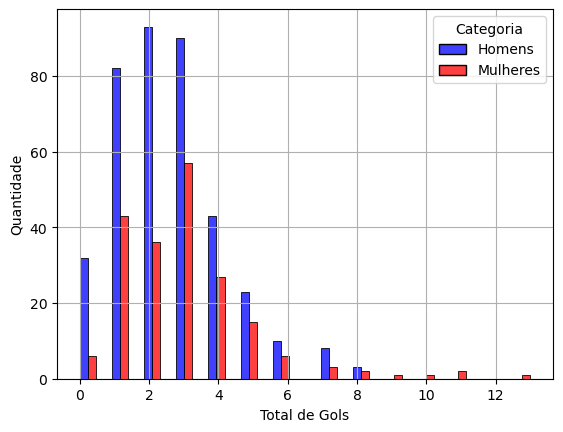

In [14]:
dados = pd.DataFrame({
    "Total de Gols": pd.concat([
        fifa_men_results["men_total_goals"],
        fifa_women_results["women_total_goals"]
    ], ignore_index=True),
    "Categoria": (
        ["Homens"] * len(fifa_men_results) +
        ["Mulheres"] * len(fifa_women_results)
    )
})

_ = sns.histplot(
    data=dados,
    x="Total de Gols",
    hue="Categoria",
    multiple="dodge",
    palette={
        "Homens": "blue",
        "Mulheres": "red"
    }
)

_.set_xlabel("Total de Gols")
_.set_ylabel("Quantidade")
_.grid(True)

plt.show()

<div class='alert alert-info' style='font-size:20px'>

- **Explicação:** A normalidade não pôde ser identificada no gráfico, na verdade os dados tendem a se concentrar na esquerda e formar uma cauda à direita. Sendo assim, o teste de Wilcoxon-Mann-Whitney (Mann-Whitney U) será usado ao invés do teste t.

</div>

---

In [15]:
stat, p_val = mannwhitneyu(
    fifa_women_results["women_total_goals"],
    fifa_men_results["men_total_goals"],
    alternative="greater"
)

$\text{Nível de significância de }10\%$

In [16]:
significancia = 0.10

if p_val <= significancia:
    resultado = "Rejeitado"
else:
    resultado = "Aceito"

dict_resultado = {
    "p_val": p_val,
    "result": resultado
}

print(dict_resultado)

{'p_val': np.float64(0.005106609825443641), 'result': 'Rejeitado'}


<div class="alert alert-info" style="font-size: 20px">

- <b>Como o resultado:</b>
    - $p\text{-val} \approx 0.0051 < \alpha = 0.10 \; (10\% \text{ de significância})$
- Então é possível descartar a hipótese nula que propunha que o número médio de gols marcados em jogos internacionais masculinos e femininos era igual;

- Contudo, a partir da análise exploratória anterior e do valor de $p\text{-val}$, fica comprovada que a hipótese alternativa está correta, visto que o número médio de gols marcados em partidas internacionais femininas é realmente superior à quantidade média de gols marcados em partidas masculinas.
</div>